In [1]:

import os
import shutil

if os.path.exists("/kaggle/working/dataset"):
    print(" Cleaning up old data...")
    shutil.rmtree("/kaggle/working/dataset")

!pip install -q "monai[nibabel, tqdm]" torch torchvision connected-components-3d gdown

BASE_DIR = "/kaggle/working/dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR = os.path.join(BASE_DIR, "Validation")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)


files = {
    "Train_Part1.zip": "1QtSOBpyXyqiGRNEFsYZUe2Ln2j3zwp2E",
    "Train_Part2.zip": "1_HDaXfDzxpgF8ESDpG1dU4aOoLt8x08k",
    "Train_Part3.zip": "1Pcd6nNwAaVttyCDGK60BnoAFhhwtypq_",
    "Validation.zip":  "1lI3Y3UsDlsrYUMQWvd9O7L6QwgcY4pjx"
}


print(f" Starting Download & Extraction...")

for filename, file_id in files.items():
    print(f"    Downloading {filename}...")
    !gdown --id {file_id} -O {filename}
    
    
    if "Validation" in filename:
        target_dir = VAL_DIR
        print(f"    Extracting to VALIDATION folder...")
    else:
        target_dir = TRAIN_DIR
        print(f"    Extracting to TRAIN folder...")
        
    !unzip -qo {filename} -d {target_dir}
    os.remove(filename) 

print(" DONE. Data is strictly separated:")
print(f"   Training Data:   {TRAIN_DIR}")
print(f"   Validation Data: {VAL_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 43.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 84.1 MB/s eta 0:00:00
 Starting Download & Extraction...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1QtSOBpyXyqiGRNEFsYZUe2Ln2j3zwp2E
From (redirected): https://drive.google.com/uc?id=1QtSOBpyXyqiGRNEFsYZUe2Ln2j3zwp2E&confirm=t&uuid=4fecdba6-c344-4e8c-9e5a-999fb5ef277b
To: /kaggle/working/Train_Part1.zip
100%|██████████████████████████████████████| 2.15G/2.15G [00:23<00:00, 90.2MB/s]
    Extracting to TRAIN folder...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a f

In [2]:
import os
import glob
import torch
import numpy as np
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, RandCropByPosNegLabeld, RandFlipd, MapTransform
)
from monai.data import Dataset, DataLoader

class ConvertToBratsClassesd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            result.append(torch.logical_or(d[key] == 2, d[key] == 4))
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 4), d[key] == 1))
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    ConvertToBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(128, 128, 128), pos=1, neg=1, num_samples=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    ConvertToBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

def get_data_list(folder_path):
    """
    Scans a folder for patient subfolders and finds t1n, t1c, t2w, t2f, seg.
    Robust to extra subfolders (recursive search).
    """
    print(f" Scanning {folder_path}...")
    patient_dirs = sorted(glob.glob(os.path.join(folder_path, "**", "HelioGLI*"), recursive=True))
    
    data_list = []
    
    for patient_path in patient_dirs:
        if not os.path.isdir(patient_path): continue
        
        try:
            t1 = glob.glob(os.path.join(patient_path, "*t1n.nii*"))[0]
            t1ce = glob.glob(os.path.join(patient_path, "*t1c.nii*"))[0]
            t2 = glob.glob(os.path.join(patient_path, "*t2w.nii*"))[0]
            flair = glob.glob(os.path.join(patient_path, "*t2f.nii*"))[0]
            seg = glob.glob(os.path.join(patient_path, "*seg.nii*"))[0]
            
            data_list.append({
                "image": [t1, t1ce, t2, flair],
                "label": seg
            })
        except IndexError:
            continue
            
    return data_list


TRAIN_DIR = "/kaggle/working/dataset/Train"
VAL_DIR = "/kaggle/working/dataset/Validation"

train_files = get_data_list(TRAIN_DIR)
val_files = get_data_list(VAL_DIR)

print(f" FINAL SPLIT:")
print(f"    Training Patients:   {len(train_files)}")
print(f"    Validation Patients: {len(val_files)}")

train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2)

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():
2026-01-02 03:21:30.168050: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767324090.611829      80 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767324090.725197      80 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767324091.849459      80 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767324091.849510      80 computation_placer.cc:177] computation placer already registered.

 Scanning /kaggle/working/dataset/Train...
 Scanning /kaggle/working/dataset/Validation...
 FINAL SPLIT:
    Training Patients:   472
    Validation Patients: 132


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


 Starting Learning Rate Search...
   Candidates: [0.001, 0.0001, 1e-05]
----------------------------------------

 Testing Learning Rate: 0.001
   Epoch 1/2 | Train Loss: 0.8567 | Val Dice: 0.0309
   Epoch 2/2 | Train Loss: 0.7878 | Val Dice: 0.2279

 Testing Learning Rate: 0.0001
   Epoch 1/2 | Train Loss: 0.8756 | Val Dice: 0.2734
   Epoch 2/2 | Train Loss: 0.8316 | Val Dice: 0.3528

 Testing Learning Rate: 1e-05
   Epoch 1/2 | Train Loss: 0.8667 | Val Dice: 0.0259
   Epoch 2/2 | Train Loss: 0.8312 | Val Dice: 0.0291

 TUNING COMPLETE
LR 0.001      -> Final Dice: 0.2279
LR 0.0001     -> Final Dice: 0.3528
LR 1e-05      -> Final Dice: 0.0291
----------------------------------------
 WINNER: Learning Rate = 0.0001
 Chart saved as 'lr_tuning_results.png'


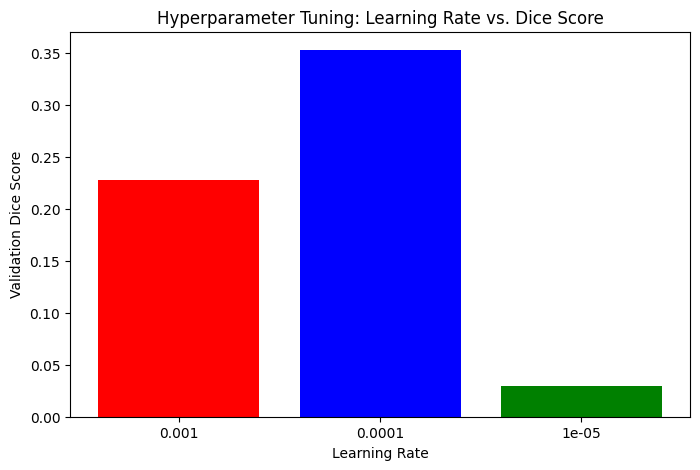

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.networks.nets import SegResNet
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="monai.inferers.utils")
warnings.filterwarnings("ignore", category=UserWarning, module="monai.transforms.spatial.array")

LEARNING_RATES = [1e-3, 1e-4, 1e-5] 
TEST_EPOCHS = 2  
VAL_INTERVAL = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = {}

print(f" Starting Learning Rate Search...")
print(f"   Candidates: {LEARNING_RATES}")
print("-" * 40)

for lr in LEARNING_RATES:
    print(f"\n Testing Learning Rate: {lr}")

    model = SegResNet(
        spatial_dims=3, in_channels=4, out_channels=3, 
        init_filters=16, dropout_prob=0.2
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
    scaler = torch.amp.GradScaler('cuda')
    
    epoch_losses = []
    val_scores = []
    
    for epoch in range(TEST_EPOCHS):
        model.train()
        step = 0
        running_loss = 0
        
        for i, batch_data in enumerate(train_loader):
            if i > 50: break 
            
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            step += 1
            
        avg_loss = running_loss / step
        epoch_losses.append(avg_loss)
        
        model.eval()
        with torch.no_grad():
            dice_vals = []
            for k, val_data in enumerate(val_loader):
                if k > 20: break 
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                val_outputs = sliding_window_inference(val_inputs, (128, 128, 128), 4, model, overlap=0.5)
                val_outputs = (val_outputs.sigmoid() > 0.5).float()
                dice = (2 * (val_outputs * val_labels).sum()) / (val_outputs.sum() + val_labels.sum() + 1e-5)
                dice_vals.append(dice.item())
            
            mean_dice = np.mean(dice_vals)
            val_scores.append(mean_dice)
            
        print(f"   Epoch {epoch+1}/{TEST_EPOCHS} | Train Loss: {avg_loss:.4f} | Val Dice: {mean_dice:.4f}")


    results[lr] = val_scores[-1]


print("\n" + "="*40)
print(" TUNING COMPLETE")
print("="*40)
best_lr = max(results, key=results.get)

for lr, score in results.items():
    print(f"LR {lr:<10} -> Final Dice: {score:.4f}")

print("-" * 40)
print(f" WINNER: Learning Rate = {best_lr}")

plt.figure(figsize=(8, 5))
plt.bar([str(lr) for lr in results.keys()], results.values(), color=['red', 'blue', 'green'])
plt.title("Hyperparameter Tuning: Learning Rate vs. Dice Score")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Dice Score")
plt.savefig("lr_tuning_results.png")
print(" Chart saved as 'lr_tuning_results.png'")

In [4]:
import torch
import torch.nn as nn
from monai.networks.nets import SegResNet
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
import numpy as np

MAX_EPOCHS = 20
VAL_INTERVAL = 2
LEARNING_RATE = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SegResNet(
    spatial_dims=3, 
    in_channels=4, 
    out_channels=3, 
    init_filters=16, 
    dropout_prob=0.2
).to(device)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print(f" Starting Training for {MAX_EPOCHS} epochs...")

for epoch in range(MAX_EPOCHS):
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / step
    epoch_loss_values.append(avg_loss)
    print(f"Epoch {epoch + 1}/{MAX_EPOCHS} | Loss: {avg_loss:.4f}", end="")

    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        with torch.no_grad():
            dice_vals = []
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                
                val_outputs = sliding_window_inference(val_inputs, (128, 128, 128), 4, model, overlap=0.5)
                val_outputs = (val_outputs.sigmoid() > 0.5).float()
                
                dice = (2 * (val_outputs * val_labels).sum()) / (val_outputs.sum() + val_labels.sum() + 1e-5)
                dice_vals.append(dice.item())

            mean_dice = np.mean(dice_vals)
            metric_values.append(mean_dice)
            print(f" | Val Dice: {mean_dice:.4f}")
            
            if mean_dice > best_metric:
                best_metric = mean_dice
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print(f"    New Best Model Saved! (Dice: {best_metric:.4f})")
    else:
        print("")

print(f"\n Training Complete.")
print(f"   Best Dice: {best_metric:.4f} at Epoch {best_metric_epoch}")
print(f"   Model saved to: best_metric_model.pth")

 Starting Training for 20 epochs...
Epoch 1/20 | Loss: 0.8063
Epoch 2/20 | Loss: 0.7146 | Val Dice: 0.5212
    New Best Model Saved! (Dice: 0.5212)
Epoch 3/20 | Loss: 0.5981
Epoch 4/20 | Loss: 0.4879 | Val Dice: 0.6864
    New Best Model Saved! (Dice: 0.6864)
Epoch 5/20 | Loss: 0.4209
Epoch 6/20 | Loss: 0.3521 | Val Dice: 0.7518
    New Best Model Saved! (Dice: 0.7518)
Epoch 7/20 | Loss: 0.3183
Epoch 8/20 | Loss: 0.2792 | Val Dice: 0.7949
    New Best Model Saved! (Dice: 0.7949)
Epoch 9/20 | Loss: 0.2696
Epoch 10/20 | Loss: 0.2711 | Val Dice: 0.7935
Epoch 11/20 | Loss: 0.2691
Epoch 12/20 | Loss: 0.2485 | Val Dice: 0.8313
    New Best Model Saved! (Dice: 0.8313)
Epoch 13/20 | Loss: 0.2437
Epoch 14/20 | Loss: 0.2260 | Val Dice: 0.8338
    New Best Model Saved! (Dice: 0.8338)
Epoch 15/20 | Loss: 0.2375
Epoch 16/20 | Loss: 0.2002 | Val Dice: 0.8533
    New Best Model Saved! (Dice: 0.8533)
Epoch 17/20 | Loss: 0.2174
Epoch 18/20 | Loss: 0.2189 | Val Dice: 0.8552
    New Best Model Saved! (Di